<h3>Проект: Анализ продаж интернет-магазина</h3>
<p><b>Цель: </b>Провести базовый анализ данных и визуализировать ключевые метрики.</p>

<ol>
    <li>Загрузить данные (создать DataFrame вручную или сгенерировать).</li>
    <li>
        Провести предобработку:
        <ul>
            <li>пропуски</li>
            <li>дубликаты</li>
            <li>типы данных</li>
        </ul>
    </li>
    <li>
        Создать дополнительные признаки:
        <ul>
            <li>месяц</li>
            <li>прибыль</li>
            <li>категория продаж</li>
        </ul>
    </li>
    <li>
        Провести анализ:
        <ul>
            <li>общие показатели</li>
            <li>топ-10 товаров</li>
            <li>распределение продаж</li>
            <li>продажи по месяцам</li>
            <li>продажи по категориям</li>
        </ul>
    </li>
    <li>
        Построить графики:
        <ul>
            <li>гистограмма</li>
            <li>boxplot</li>
            <li>barplot</li>
            <li>lineplot</li>
        </ul>
    </li>
</ol>


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.random.seed(42)

n = 300

products = ["Phone", "Laptop", "Tablet", "Headphones", "Smartwatch"]
categories = ["Electronics", "Accessories"]

df = pd.DataFrame({
    "order_id": np.arange(1, n + 1),
    "product": np.random.choice(products, n),
    "category": np.random.choice(categories, n),
    "price": np.random.randint(100, 1500, n),
    "quantity": np.random.randint(1, 5, n),
    "date": pd.date_range("2023-01-01", periods=n, freq="D")
})

df.loc[np.random.randint(0, n, 10), "price"] = np.nan

print("Первые строки:")
print(df.head())

Первые строки:
   order_id     product     category   price  quantity       date
0         1  Headphones  Electronics   762.0         3 2023-01-01
1         2  Smartwatch  Accessories  1313.0         1 2023-01-02
2         3      Tablet  Electronics   136.0         1 2023-01-03
3         4  Smartwatch  Electronics  1492.0         2 2023-01-04
4         5  Smartwatch  Accessories   378.0         4 2023-01-05


In [8]:
print(f"Информация: \n {df.info()}" )

print(f"Пропуски: \n {df.isnull().sum()}")
df = df.dropna()
print(df.isnull().sum())
print(f"Дубликаты: \n {df.duplicated().sum()}")


<class 'pandas.core.frame.DataFrame'>
Index: 290 entries, 0 to 299
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   order_id  290 non-null    int64         
 1   product   290 non-null    object        
 2   category  290 non-null    object        
 3   price     290 non-null    float64       
 4   quantity  290 non-null    int32         
 5   date      290 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(2)
memory usage: 14.7+ KB
Информация: 
 None
Пропуски: 
 order_id    0
product     0
category    0
price       0
quantity    0
date        0
dtype: int64
order_id    0
product     0
category    0
price       0
quantity    0
date        0
dtype: int64
Дубликаты: 
 0


In [9]:
df['total'] = df['price'] * df['quantity']
df['month'] = df['date'].dt.month
df['sales_group'] = pd.cut(
    df['total'],
    bins = [0, 500, 1500, 5000],
    labels = ['Low', 'Medium', 'High']
)

In [16]:
print(f"Статистика: \n {df.describe()}")
print("\n \n")
print("ТОП 5 товаров по прибыли: ")
print(df.groupby('product')['total'].sum().sort_values(ascending=False).head(5))

monthly_sales = df.groupby('month')['total'].sum()


Статистика: 
          order_id        price    quantity                           date  \
count  290.000000   290.000000  290.000000                            290   
mean   151.444828   837.134483    2.420690  2023-05-31 10:40:33.103448320   
min      1.000000   100.000000    1.000000            2023-01-01 00:00:00   
25%     77.250000   495.250000    1.000000            2023-03-18 06:00:00   
50%    151.500000   863.000000    2.000000            2023-05-31 12:00:00   
75%    226.750000  1200.000000    3.000000            2023-08-14 18:00:00   
max    300.000000  1497.000000    4.000000            2023-10-27 00:00:00   
std     86.773252   416.349242    1.098404                            NaN   

             total       month  
count   290.000000  290.000000  
mean   2027.893103    5.496552  
min     136.000000    1.000000  
25%     854.750000    3.000000  
50%    1630.000000    5.500000  
75%    2898.000000    8.000000  
max    5832.000000   10.000000  
std    1428.690878    2.8506

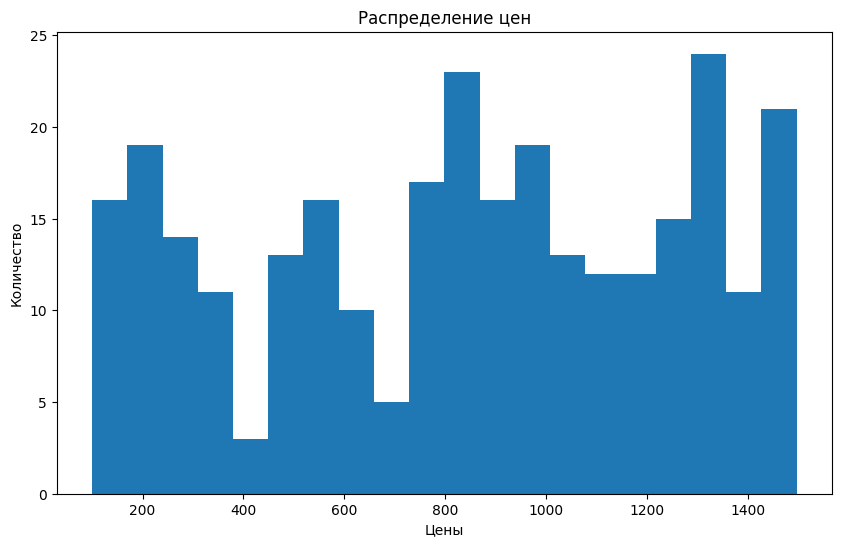

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=20)
plt.title("Распределение цен")
plt.xlabel("Цены")
plt.ylabel("Количество")
plt.show()

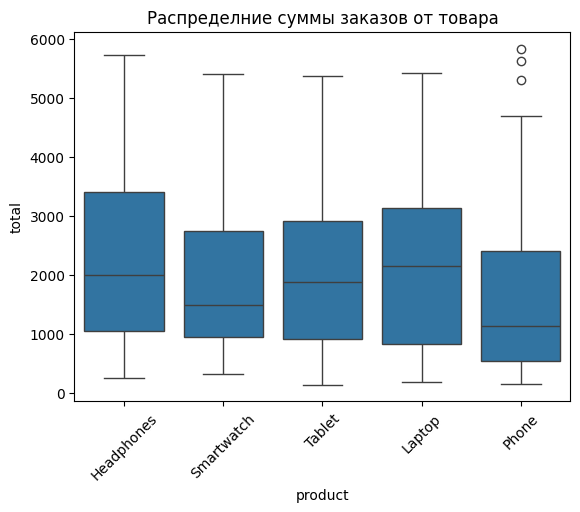

In [18]:
sns.boxplot(data=df, x='product', y='total')
plt.title("Распределние суммы заказов от товара")
plt.xticks(rotation=45)
plt.show()

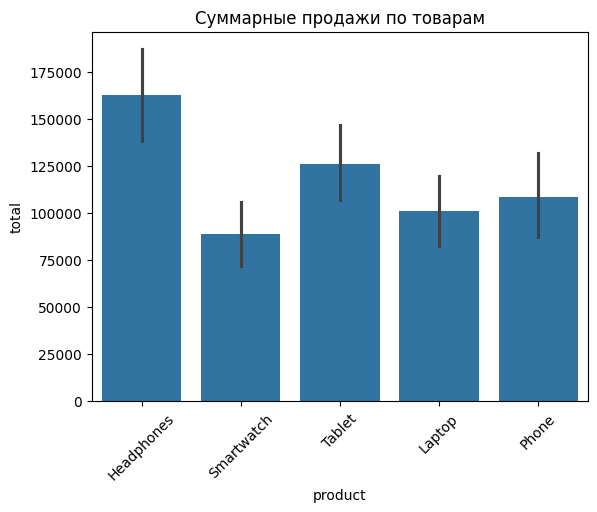

In [19]:
sns.barplot(data=df, x='product', y='total', estimator=sum)
plt.title("Суммарные продажи по товарам")
plt.xticks(rotation=45)
plt.show()

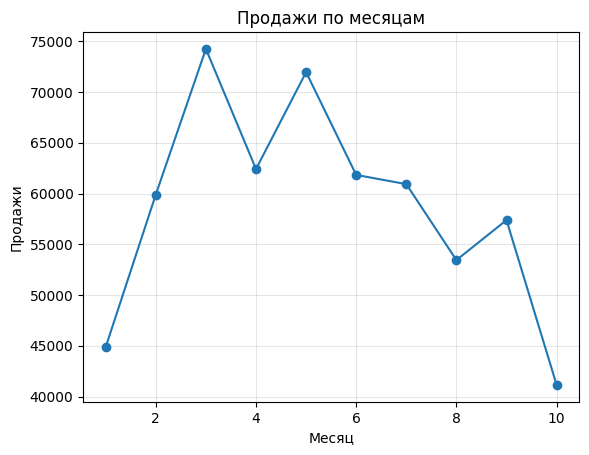

In [21]:
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Продажи по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Продажи")
plt.grid(True, alpha=0.33)
plt.show()

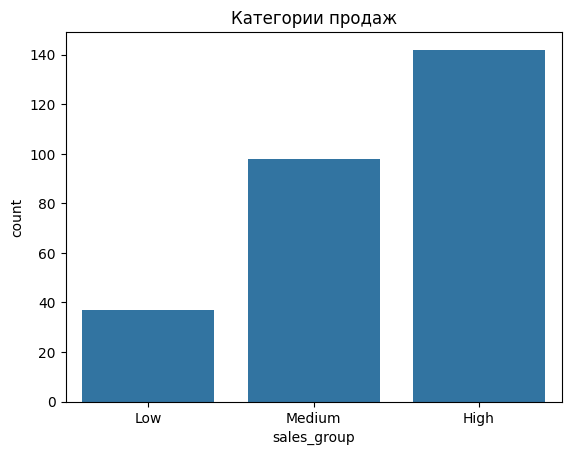

In [22]:
sns.countplot(data=df, x='sales_group')
plt.title("Категории продаж")
plt.show()

In [24]:
print('''
Выводы:
1) Данные успешно очищены от пропусков
2) Больше всего прибыли приносит продукт: headphones
3) Пиковые продажи со 2 по 4 месяц
4) Есть выбросы по товару Phone
5) Больше всего продаж с категории "High"
''')


Выводы:
1) Данные успешно очищены от пропусков
2) Больше всего прибыли приносит продукт: headphones
3) Пиковые продажи со 2 по 4 месяц
4) Есть выбросы по товару Phone
5) Больше всего продаж с категории "High"

